<a href="https://colab.research.google.com/github/Demi-Khaled/Deep-Learning/blob/main/Brain_MRI_SVM_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

print("GPU Available:",
      tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q kaggle

In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset Path: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
import os

print(os.listdir(path))

['Training', 'Testing']


In [ ]:
train_dir = os.path.join(path, 'Training')
test_dir = os.path.join(path, 'Testing')

print(train_dir)
print(test_dir)

/kaggle/input/brain-tumor-mri-dataset/Training
/kaggle/input/brain-tumor-mri-dataset/Testing


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Training Generator
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Testing Generator
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Load Training Images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Load Testing Images
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Feature Extraction Layer
x = GlobalAveragePooling2D()(base_model.output)

# Final Feature Extractor Model
feature_extractor = Model(
    inputs=base_model.input,
    outputs=x
)

print("ResNet50 Loaded Successfully")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 Loaded Successfully


In [ ]:
# Extract Training Features
train_features = feature_extractor.predict(train_generator)

# Extract Testing Features
test_features = feature_extractor.predict(test_generator)

# Labels
train_labels = train_generator.classes
test_labels = test_generator.classes

print(train_features.shape)
print(test_features.shape)

175/175 ━━━━━━━━━━━━━━━━━━━━ 102s 530ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step
(5600, 2048)
(1600, 2048)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Improved SVM
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=10,
        gamma='scale'
    ))
])

# Train
svm_model.fit(train_features, train_labels)

print("SVM Training Finished")

SVM Training Finished


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions
predictions = svm_model.predict(test_features)

# Accuracy
accuracy = accuracy_score(test_labels, predictions)

print("Accuracy:", accuracy)

# Full Report
print(classification_report(
    test_labels,
    predictions
))

Accuracy: 0.905
              precision    recall  f1-score   support

           0       0.97      0.72      0.83       400
           1       0.81      0.92      0.86       400
           2       0.91      0.99      0.95       400
           3       0.95      0.98      0.97       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.90      1600
weighted avg       0.91      0.91      0.90      1600



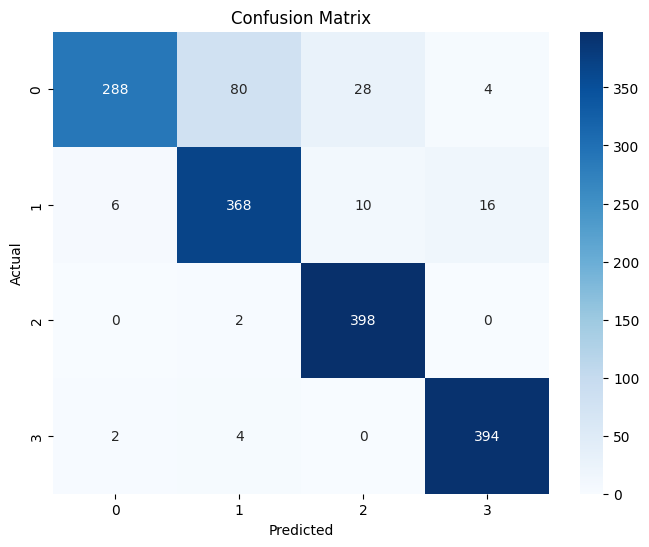

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()